# Local sensitivity

### Sensitivity (Global)

 - The amount of the function's output can change if the input changes.
 - Let $f: \mathcal{D} \rightarrow \mathbb{R}$ be a function. Then $$S(f) = GS(f) = \max_{D,D':d(D,D')\le 1} |f(D) - f(D')|$$

 - Definition consider any two datasets.
 - Can we fix one of the datasets to the actual dataset?
 
 > ### Local sensitivity
 > $$LS(f,D) = \max_{D':d(D,D')\le 1} |f(D) - f(D')|$$
 
 - Local sensitivity is a function of both the query $f$ and the actual dataset $D$. 

### Sensitivity of the Mean

 - We calculated mean query by splitting it into two DP queries: Sum + Count
 - Sequential composition implies that is DP
 - It doubles the privacy cost.   
 - Can we do it in one query?

- The output depends on the size of the dataset.
- Dataset can have only 1 element.
- If $u$ and $\ell$ are the upper and lower bounds of $f$, then the sensitivity is $|u - \ell|$. 

### Local sensitivity of the Mean

 - Mean: $$ f(x) = \frac{\sum_{i=1}^n x_i}{n}$$
 - Compute local sensitivity: 
 \begin{align*}
 f(x') - f(x) &= \left|\frac{\sum_{i=1}^n + u}{n + 1} - \frac{\sum_{i=1}^n}{n} \right| \le \\
 \le \left|\frac{\sum_{i=1}^n + u}{n + 1} - \frac{\sum_{i=1}^n}{n} \right| &= \left|\frac{\sum_{i=1}^n + u- \sum_{i=1}^n}{n + 1} \right| = \left| \frac{u}{n + 1} \right|
 \end{align*}

 - Local sensitivity: $$\frac{u}{n + 1}$$
 - If $n$ is large, $\approx 10.000$, this is much smaller than the previous one.

## DP via local sensitivity

- Laplace mechanism: $F(D) = f(D) + Lap(\frac{LS(f,x)}{\varepsilon})$
- Is this DP

 - NO. $LS(f,D)$ depends on the data. It can contain sensitive information.
 - It is possible to compute the size of the dataset (with no noise) from local sensitivity: $$ |D| = \frac{u}{LS(f,D)} -1 $$.


 ### Can we keep the local sensitivity secret?
 
 - It is possible to determine the scale of the noise just from a few queries.
 - DP protect the data, not the sensitivity.
 - If using global sensitivity, it is not a problem, as it is public.
 - Sensitive query: *Average score of people named Joe in the dataset with a 98% on the exam?*

## Propose-Test-Release

 - Problem: local sensitivity reveals something about the data.
 - Idea: make the sensitivty itself DP.
 - It is challenging if there is no bound on the global sensitivity of local sensitivity.

 1. The analyst proposes an upper bound for local sensitivity.
 2. The curator runs a DP test to check if the dataset being queried is *far from* a dataset where local sensitivity is higher than the proposed bound.
 3. If the test passes, the curator calibrates the noise with the proposed bound.

> ### Maximum Local Sensitivity
> $$ A(f,D,k) = \max_{D':d(D,D') \le k} LS(f,D')

 - $A(f,D,k)$ is the maximum local sensitivity achievable for $f$ by taking $k$ steps away from dataset $D$.
 - If $A(f,D,1)$ is local sensitivity.  

> ### Minimal step 
> $$ T(f,D,b) = \argmin_k A(f,D,k) > b $$

 - Number of steps needed to achieve greater local sensitvity than $b$.

> ### Propose-Test-Release Framework
> 1. Propose a target bound $b$ on local sensitivity.
> 2. If $T(f,D,b) + Lap(\frac{1}{\varepsilon} < \frac{\log(2/\delta)}{2\varepsilon}$, return $\perp$.
> 3. Return $f(x) + Lap(\frac{b}{\varpesilon})

The framework satisfies $(\varepsilon,\delta)$-DP.

### Algorithm explonation

- Why the framework don't release anything if $T(f,D,b)$ is too small?
- Why we add noise in step 2?
- Why is it $(\varepsilon,\delta)$-DP and not $\epsilon$-DP.
- What is the privacy cost if returns $\perp$.

 - If $T(f,D,b)$ is small, for example 1, then $b$ bounds the local sensitivity. Using $b$ in the Laplace mechanism (like in step 3.) can expose the local sensitivity.
 - The analyser might use $b$ to infer information from $T(b,D,b)$. Suppose that $A(f,D,k) \approx k \cdot LS(f)$. Then $A(f,D,k) > k$ implies that $S(f) > b/k$ and $A(f,D,k) < b$ implies that $LS(f) < b/k$. Running the framework until it doesn't output $\perp$ reveals $S(f)$.
 - There is a small chance, that $T(b,D,b)$ is not large enough to pass the test, but the noise is so large, that it passes. In that case, the algortihm exctually releases sensitive information.
 - The privacy cost is $(\varepsilon,\delta)$, even if it returns $\perp$. The reasos for this, is tht it also yields informtion for the analyst, like we saw before.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def laplace_mech(v, sensitivity, epsilon):
    return v + np.random.laplace(loc=0, scale=sensitivity/epsilon)
def pct_error(orig, priv):
    return np.abs(orig - priv)/orig * 100.0
adult = pd.read_csv("data.csv")

In [2]:
def ls_at_distance(df, u, k):
    return np.abs(u/(len(df) - k + 1))

def dist_to_high_ls(df, u, b):
    k = 0
    
    while ls_at_distance(df, u, k) < b:
        k += 1
    
    return k

In [3]:
def ptr_avg(df, u, b, epsilon, delta, logging=False):
    df_clipped = df.clip(upper=u)
    k = dist_to_high_ls(df_clipped, u, b)

    noisy_distance = laplace_mech(k, 1, epsilon)
    threshold = np.log(2/delta)/(2*epsilon)

    if logging:
        print(f"Noisy distance is {noisy_distance} and threshold is {threshold}")

    if noisy_distance >= threshold:
        return laplace_mech(df_clipped.mean(), b, epsilon)
    else:
        return None

In [4]:
df = adult['Age']
u = 100                    # set the upper bound on age to 100
epsilon = 1                # set epsilon = 1
delta = 1/(len(df)**2)     # set delta = 1/n^2
b = 0.006                  # propose a sensitivity of 0.005

ptr_avg(df, u, b, epsilon, delta, logging=True)

Noisy distance is 3333.6230829601545 and threshold is 10.2500611428161


41.013614017923516

Let's compare the result with our old strategy of splitting the query into two separte queries (sum and count), both with bounded global sensitivities. 

In [5]:
def gs_avg(df, u, epsilon):
    df_clipped = df.clip(upper=u)
    
    noisy_sum = laplace_mech(df_clipped.sum(), u, .5*epsilon)
    noisy_count = laplace_mech(len(df_clipped), 1, .5*epsilon)
    
    return noisy_sum / noisy_count

In [6]:
gs_avg(adult['Age'], u, epsilon)

41.0045843075079

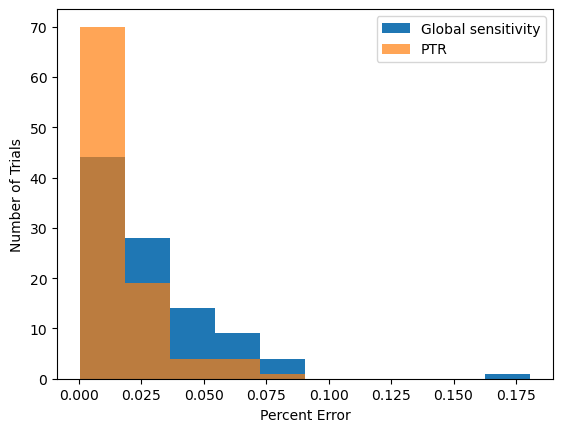

In [7]:
gs_results  = [pct_error(np.mean(adult['Age']), gs_avg(df, u, epsilon)) for i in range(100)]
ptr_results = [pct_error(np.mean(adult['Age']), ptr_avg(df, u, b, epsilon, delta)) for i in range(100)]

_, bins, _ = plt.hist(gs_results, label='Global sensitivity');
plt.hist(ptr_results, alpha=.7, label='PTR', bins=bins);
plt.xlabel('Percent Error')
plt.ylabel('Number of Trials')
plt.legend();

### Performance Comparison

 - We might do slightly better with propose-test-release, but it's not a huge difference.
 - To use propose-test-release, the analyst has to propose a bound sensitivity.
 - The performance is based on the choice of $b$. If $b = 0.02$, then global sensitivity gives better results.
 - If the analyst chooses 

## Smooth Sensitivity

 - Nissim, Raskhodnikova, Smith 
 - Provides $(\varepsilon,\delta)$-DP

> ### Smooth Sensitivity Frmework
> 1. Set $\beta = \frac{\varepsilon}{2\log(2/\delta)}$
> 2. Let $S = \max_{k=1,\dots,n} e^{-\beta k} A(f,D,k)$
> 3. Release $f(x) + Lap(\frac{2S}{\varepsilon})$

 - Idea: use smooth approxiamtion instead of local sensitivity
 - The amunt of smoothing is designed to prevent the unintetional release of information.
 - If a spike in local sensitivity exists in the local neighborhood of $D$, that spike will be smooothed out.

### Advanteges:

 - It doesn't require the analyst to propose a bound on sensitivity. 

### Disadvanteges:

 - Larger than local sensitivity by at least a factor of 2 (by step 3).
 - Requires finding the maximum smoothed-out sensitivity over all possible values for $k$. In many cases it is enough to consider a small number of values for $k$ (for most functions, $e^{-\beta k}$ quickly overwhelms the growing value of $A(f,D,k)$).  

Final sensitivity: 0.00999950002499875


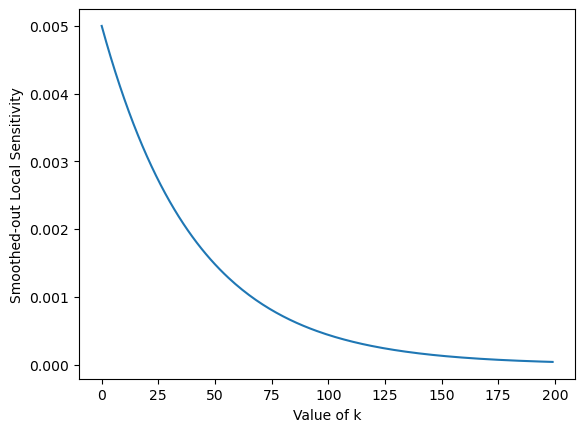

In [8]:
df = adult['Age']
epsilon = 1           # set epsilon = 1
delta = 1/len(df)**2  # set delta = 1/n^2

# Step 1: set beta
beta = epsilon / (2*np.log(2/delta))

# Step 2: compute smoothed-out sensitivity for various values of k
r = [np.exp(- beta * k) * ls_at_distance(df, u, k) for k in range(0,200)]
plt.plot(r);
plt.xlabel('Value of k')
plt.ylabel('Smoothed-out Local Sensitivity');

S = np.max(r)
sensitivity = 2*S
print(f'Final sensitivity: {sensitivity}')

 - It is clear, that the smoothed-out local sensitivity approaches 0, as $k$ grows.
 - The maximum occurs at $k = 0$.
 - If we want to use smooth sensitivity, we need to prove this.
 - The sensitivity is slightly worse then what the porpose-test-release gives.

## Sample and Aggregate

> ### Sample and Aggregate Framework
> 1. Split the datasetm $D$ into $k$ disjoint chunks, $D_1,\dots,D_k$.
> 2. Compute a clipped answer for each chunk: $a_i = \max(\ell, \min(u, f(D_i)))$.
> 3. Compute a noisy average of the answer: $A = \left(\frac{1}{k} \sum_{i=1}^k a_i\right) + Lap(\frac{u - \ell}.{k\varepsilon}$.

$u$ and $\ell$ are upper and lower clipping bounds. The framework satisfies $\varepsilon$-DP.

 The framework satisfies DP by global sensitivity and parallel composition.
 - We split the dataset into $k$ distinct chunks, so each individual appears in exactly one chunk. 
 - The sensitivity of $a_i$ for each chunk is $u - \ell$.
 - We take the mean of $k$ invocations of $f$, so the global sensitivity of the mean is $\frac{u-\ell}{k}.
 
Here we can compute the sensitivity of the mean, because the number of chunks is fixed and public (chosen by the analyst).

How to chose $u$ and $\ell$?

 - The analyst have to provide $u$ and $\ell$
 - Without any knowledge, it is really hard to choose good values.
 - Niism, Raskhodnikova, Smith proposed a variant leverage local sensitivity to avoid asking the analyst for $u$ and $\ell$. 
 - For some function, like age, it is easy to bound $f$.

In [9]:
def f(df):
    return df.mean()

def saa_avg_age(k, epsilon, logging=False):
    df = adult['Age']
    
    # Calculate the number of rows in each chunk
    chunk_size = int(np.ceil(df.shape[0] / k))
    
    if logging:
        print(f'Chunk size: {chunk_size}')
        
    # Step 1: split `df` into chunks
    xs      = [df[i:i+chunk_size] for i in range(0,df.shape[0],chunk_size)]
    
    # Step 2: run f on each x_i and clip its output
    answers = [f(x_i) for x_i in xs]
    
    u = 80
    l = 20
    clipped_answers = np.clip(answers, l, u)
    
    # Step 3: take the noisy mean of the clipped answers
    noisy_mean = laplace_mech(np.mean(clipped_answers), (u-l)/k, epsilon)
    return noisy_mean

saa_avg_age(600, 1, logging=True)

Chunk size: 34


41.04790294117213

**How to choose $k$?**

 - If $k$ goes up, th final noisy mean goes down., so more chunks less noise.
 - If $k$ goes up, each chunk gets smaller, so each answer $f(D_i)$ is less accurate.
 
 We try a few different values of $k$ for our age example.

In [10]:
def plot_results(k):
    df = adult['Age']
    _, bins, _ = plt.hist([pct_error(np.mean(df), saa_avg_age(k, epsilon)) for i in range(100)], label = 'Sample & Aggregate');
    plt.hist([pct_error(np.mean(df), gs_avg(df, u, epsilon)) for i in range(100)], alpha=.7, bins=bins, label = 'Globas Sensitivity');

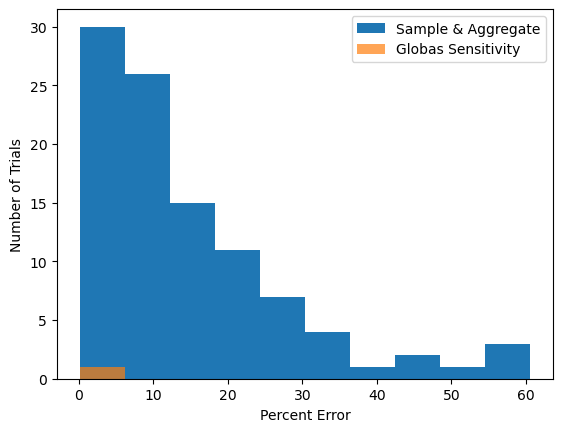

In [11]:
# k = 10; global sensitivity is *much* better
plot_results(10)
plt.xlabel('Percent Error')
plt.ylabel('Number of Trials')
plt.legend();

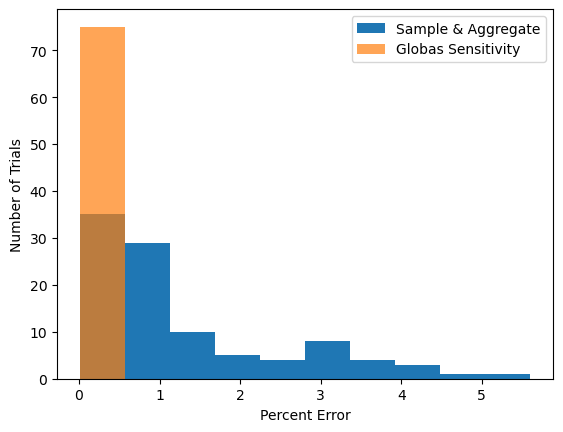

In [12]:
# k = 100; global sensitivity is still better
plot_results(100)
plt.xlabel('Percent Error')
plt.ylabel('Number of Trials')
plt.legend();

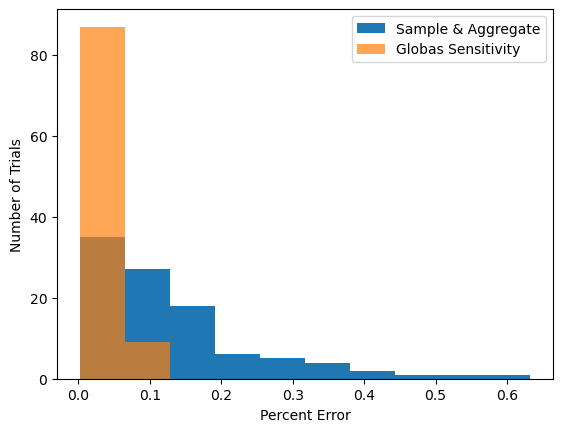

In [13]:
# k = 1000; sample and aggregate is getting close!
plot_results(1000)
plt.xlabel('Percent Error')
plt.ylabel('Number of Trials')
plt.legend();

In [ ]:
# k = 6000; sample and aggregate is getting close!
plot_results(6000)
plt.xlabel('Percent Error')
plt.ylabel('Number of Trials')
plt.legend();

### Conclusion 

 - Sample and aggregate only comes close to the accuracy of global sensitvity for large values of $k$. 
 - The big advantage is that it works for any function $f$, regardless of its sensitivity. If $f$ is nice, then it is possible to obtain good accuracy.
 - The disadvante is the analyst has to set the bounds ($u$ and $\ell$) and the the number of chunks ($k$). If $f$ is not nice, and the analyst has no information on the dataset, then it is pretty hard to choose this values right.

## Variants of DP

 We already see two different DP definitions
  - $\varepsilon$-DP (pure DP)
  - $(\varepsilon,\delta)$-DP (approximate DP)
  
 There are other vairants of DP.

###  Rényi DP

 - Mironov proposed it in 2017
 - It has two parameters, $(\alpha, \overline{\varepsilon})$ 
 - If $M$ satisfies $(\alpha, \overline{\varepsilon})$-RDP, then for $\delta > 0$, $M$ satisfies $(\varepsilon,\delta)$-DP for $\varepsilon = \overline{\varepsilon} + \frac{\log(1/\delta)}{\alpha -1}$.
 - The following mechanism satisfies Rényi DP. $\Delta f$ is the $L2$ sensitivity.
 
> ### Renyi Gaussian 
> $$M(x) = f(x) + \mathcal{N}(\sigma^2) \text{ where } \sigma^2 = \frac{\Delta f^2\alpha}{2 \overline{\varepsilon}}$$

In [ ]:
def gaussian_mech_RDP_vec(vec, sensitivity, alpha, epsilon_bar):
    sigma = np.sqrt((sensitivity**2 * alpha) / (2 * epsilon_bar))
    return [v + np.random.normal(loc=0, scale=sigma) for v in vec]

###  Zero-Concentrated DP

 - Bun and Steinke porosed it in 2016.
 - Only one parameter, $\rho$ 
 - If $M$ satisfies $\rho$-zCDP, then for $\delta > 0$, $M$ satisfies $(\varepsilon,\delta)$-DP for $\varepsilon = \rho + 2\sqrt{\rho \log(1/\delta)}$.
 - The following mechanism satisfies zCDP. $\Delta f$ is the $L2$ sensitivity.
 
> ### zCDP Gaussian 
> $$M(x) = f(x) + \mathcal{N}(\sigma^2) \text{ where } \sigma^2 = \frac{\Delta f^2\alpha}{2 \rho}$$

In [ ]:
def gaussian_mech_zCDP_vec(vec, sensitivity, rho):
    sigma = np.sqrt((sensitivity**2) / (2 * rho))
    return [v + np.random.normal(loc=0, scale=sigma) for v in vec]

### Sequential Composition 

> ### Renyi-Sequential-Compostion
> If $M_1$ satisfies $(\alpha, \overline{\varepsilon}_1)$-RDP and $M_2$ satisfies $(\alpha, \overline{\varepsilon}_2)$-RDP, then their composition satisfies $(\alpha, \overline{\varepsilon}_1 + \overline{\varepsilon}_2)$-RDP

> ### zCDP-Sequential-Compostion
> If $M_1$ satisfies $(\rho_1)$-zCDP and $M_2$ satisfies $(\rho_2)$-zCDP, then their composition satisfies $(\rho_1 + \rho_2)$-zCDP

### Composition under Variants of DP

  - Which variant of DP shoud we use and when?  
  - GDP and zCDP yield significantly tighter bounds on privacy cost when
      - The Gaussian mechanism is used (especially on high-dimensional vectors)
      - The algorithm in question applies the mechanism many times (e.g. hundreds or thousands of times) 
  - To use RDP and zCDP, we implement the algorithm we want to use, and then convert the total privacy cost back to $(\varepsilon,\delta)$-DP, so we can compare the algorithms.

In [ ]:
sigma = 200.0
delta = 1e-5
lap_eps = 2*sigma**2
xs = np.linspace(0, 500, 100)

gauss_eps = np.sqrt(2 * np.log(1.25/delta) / sigma**2)

ys_gauss_adv = [2 * gauss_eps * np.sqrt(2 * x * np.log(1/delta)) for x in xs]

rho = 1/(2*sigma**2)
ys_gauss_zcdp = [(x*rho) + 2*np.sqrt((x*rho) * np.log(1/delta)) for x in xs]

alpha = 60
rdp_eps = alpha / (2*sigma**2)

ys_gauss_rdp = [(x*rdp_eps) + np.log(1/delta)/(alpha-1) for x in xs]

ys_moments = [4*np.sqrt(x*np.log(1/delta))/sigma for x in xs]

plt.plot(xs, ys_gauss_adv, label="Gaussian+Adv. Comp.")
plt.plot(xs, ys_gauss_zcdp, label="Gaussian+zCDP")
plt.plot(xs, ys_gauss_rdp, label="Gaussian+RDP")
#plt.plot(xs, ys_moments, label="Moments Accountant")

plt.xlabel('Number of Iterations')
plt.ylabel('Epsilon')
plt.ylim(0, 3.0)


plt.legend()
plt.show();

 - Using sequential composition under either zCDP or RDP is much better than using advanced composition with $(\varepsilon,\delta)-$DP.
 - RDP is linear for fixed $\alpha$. Try different values for find the best result.
 - zCDP is sublinear

## Exponential mechanism

 - Laplace and Gaussain mechanism are focused on numerical answer and add noise directly to the answer itself.
 - How to return a precise answer but still preserve differential privacy?
 - Example: What marital status has the most indivdual?
 

 - Define best by a scoring function.
 - Return an answer based on the score.

> ### Exponential Mechansim
> 1. The analyst select a set $R$ of possible outputs.
> 2. The analyst specifies a scoirng function $u: \mathcal{D}\times R \rightarrow \mathbb{R}$ with global sensitivity $\Delta u$.
> 3. The exponenetial mechansim outputs $r \in R$ with probability proportinal to: $$ \exp\left(\frac{\varepsilon u(D,r)}{2\Delta u}\right)$$

The exponential mechanism satisfies $\varepsilon$-DP.

### Properties:

 - Exponential mechansim always output an element of $R$. 
 - The privacy cost is $\varepsilon$ regardless the size of $R$.
 - It is a *fundamental mechanism*: every other $\varepsilon$-DP mechanism can be defined in terms of exponential mechanism with the appropriate scoirng function.

In [ ]:
options = adult['Marital Status'].unique()

def score(data, option):
    return data.value_counts()[option]/1000

score(adult['Marital Status'], 'Never married')

In [ ]:
def exponential(x, R, u, sensitivity, epsilon):
    # Calculate the score for each element of R
    scores = [u(x, r) for r in R]
    
    # Calculate the probability for each element, based on its score
    probabilities = [np.exp(epsilon * score / (2 * sensitivity)) for score in scores]
    
    # Normalize the probabilties so they sum to 1
    probabilities = probabilities / np.linalg.norm(probabilities, ord=1)

    # Choose an element from R based on the probabilities
    return np.random.choice(R, 1, p=probabilities)[0]

exponential(adult['Marital Status'], options, score, 1, 1)

In [ ]:
r = [exponential(adult['Marital Status'], options, score, 1, 1) for i in range(200)]
pd.Series(r).value_counts()

## Report Noisy Max

Consider the following mechanism:

> ### Report Noisy Max
> 1. For each $r \in R$, calculate a *noisy score* $u(D,r) + Lap(\frac{\Delta u}{\varepsilon}$.
> 2. Output the element $r\in R$ with the maximum noisy score.

 - The scoring function $u$ is $\Delta u$ sensitive, so each *query* in step 1 satisfies $\varepsilon$-DP.
 - Thus the total privacy cost is $|R|\varepsilon$.
 - However the privacy cost for exponential mechanism is $\varepsilon$. 
 - Why is the exponential mechanism better?

 - We count the privacy cost too roughly.
 - $|R|\varepsilon$ is the privacy cost, if the curator outputs every result in step 1. 
 - The real privacy cost of Report Noisy Max is the same as the exponential mechanism: $\varepsilon$. 

In [ ]:
def report_noisy_max(x, R, u, sensitivity, epsilon):
    # Calculate the score for each element of R
    scores = [u(x, r) for r in R]

    # Add noise to each score
    noisy_scores = [laplace_mech(score, sensitivity, epsilon) for score in scores]

    # Find the index of the maximum score
    max_idx = np.argmax(noisy_scores)
    
    # Return the element corresponding to that index
    return R[max_idx]

report_noisy_max(adult['Marital Status'], options, score, 1, 1)

In [ ]:
r = [report_noisy_max(adult['Marital Status'], options, score, 1, 1) for i in range(200)]
pd.Series(r).value_counts()